## Araç fiyat Tahmin Modeli Geliştirme ve yayma (Deploy)

### 1. Kütüphaneleri Yükle

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


## 2. Veri Setinin yüklenmesi

In [119]:
data_url=r"https://github.com/yapayzekaokulum/vb-90-2/raw/main/data/cars.xls"

In [120]:
df=pd.read_excel(data_url)

In [121]:
df.head() # data frame deki ilk satırları getirir

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


## 3. Veri Ön İşleme (Keşifsel Veri Analizi)

In [122]:
df.info() #veri seti hakkında bilgi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Model     804 non-null    object 
 4   Trim      804 non-null    object 
 5   Type      804 non-null    object 
 6   Cylinder  804 non-null    int64  
 7   Liter     804 non-null    float64
 8   Doors     804 non-null    int64  
 9   Cruise    804 non-null    int64  
 10  Sound     804 non-null    int64  
 11  Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 75.5+ KB


In [123]:
df.describe() # tanımlayıcı istatistikler

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,21343.143767,19831.934080,5.268657,3.037313,3.527363,0.752488,0.679104,0.723881
std,9884.852801,8196.319707,1.387531,1.105562,0.850169,0.431836,0.467111,0.447355
min,8638.930895,266.000000,4.000000,1.600000,2.000000,0.000000,0.000000,0.000000
25%,14273.073870,14623.500000,4.000000,2.200000,4.000000,1.000000,0.000000,0.000000
50%,18024.995019,20913.500000,6.000000,2.800000,4.000000,1.000000,1.000000,1.000000
75%,26717.316636,25213.000000,6.000000,3.800000,4.000000,1.000000,1.000000,1.000000
max,70755.466717,50387.000000,8.000000,6.000000,4.000000,1.000000,1.000000,1.000000


In [124]:
df['Cylinder'] # tek bir sütun seçmek

,Cylinder
0,6
1,6
2,6
3,6
4,6
...,...
799,6
800,6
801,6
802,6


In [125]:
df['Cylinder'].value_counts()

,count
Cylinder,
4,394
6,310
8,100


<Axes: ylabel='count'>

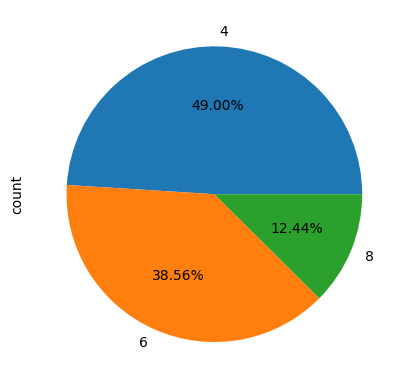

In [126]:
df['Cylinder'].value_counts().plot(kind='pie',
                                   autopct='%.2f%%')

<Axes: xlabel='Make'>

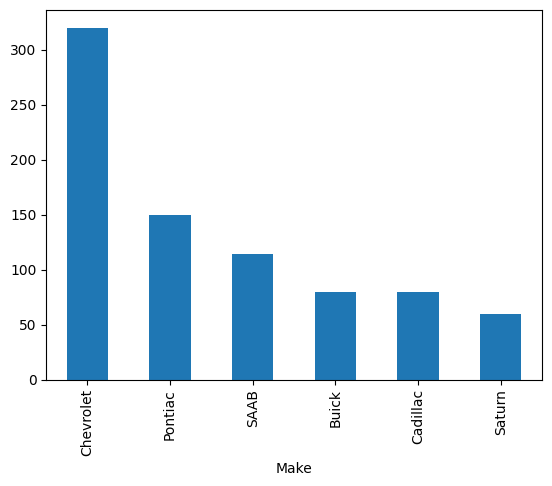

In [127]:
df['Make'].value_counts().plot(kind='bar')

In [128]:
# En pahalı araç
df[df['Price']==df['Price'].max()]

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
150,70755.466717,583,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1


In [129]:
df['Price'].max(), df['Price'].min()

(70755.46671654288, 8638.930895260657)

In [130]:
# 50 K üstü araçlar
df[df['Price']>=50000]

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
80,51154.047216,2202,Cadillac,CST-V,Sedan 4D,Sedan,8,5.7,4,1,1,1
150,70755.466717,583,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
151,68566.187189,6420,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
152,69133.731722,7892,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
153,66374.307040,12021,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
154,65281.481237,15600,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
155,63913.117248,18200,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
156,60567.549093,23193,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
157,57154.443437,29260,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,1,1
158,55639.087654,31805,Cadillac,XLR-V8,Hardtop Conv 2D,Convertible,8,4.6,2,1,0,1


In [131]:
len(df[df['Price']>=50000])

11

<Axes: >

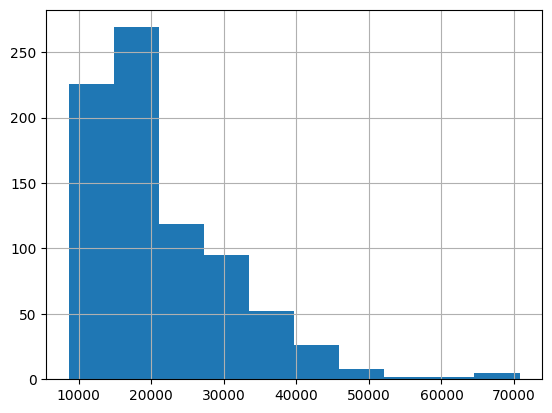

In [132]:
#Araçların fiyat dağılımı
df['Price'].hist()

In [133]:
# Veri setini özellikler(X) ve y (hedef) oalrak ayır
y=df['Price'] #hedef sütun
X=df.drop('Price', axis=1) # price dışında kalan tüm sütunlar
#X=df[['Make', 'Model'....]]

In [134]:
X

,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
799,16229,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,0,0
800,19095,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
801,20484,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0
802,25979,Saturn,L Series,L300 Sedan 4D,Sedan,6,3.0,4,1,1,0


In [135]:
y

,Price
0,17314.103129
1,17542.036083
2,16218.847862
3,16336.913140
4,16339.170324
...,...
799,16507.070267
800,16175.957604
801,15731.132897
802,15118.893228


In [136]:
# modeli eğitmek ve test etmek için veri setini eğitim ve test oalrak böl
X_train,X_test,y_train, y_test=train_test_split(X,y,
                                                test_size=0.2,
                                                random_state=42)

In [137]:
X_train.shape,y_train.shape

((643, 11), (643,))

In [138]:
X_test.shape,y_test.shape

((161, 11), (161,))

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Model     804 non-null    object 
 4   Trim      804 non-null    object 
 5   Type      804 non-null    object 
 6   Cylinder  804 non-null    int64  
 7   Liter     804 non-null    float64
 8   Doors     804 non-null    int64  
 9   Cruise    804 non-null    int64  
 10  Sound     804 non-null    int64  
 11  Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 75.5+ KB


In [140]:
cat_feat=['Make','Model','Trim','Type', 'Doors', 'Cruise', 'Sound', 'Leather']
num_feat=['Mileage','Cylinder','Liter']

## 4. Model Oluşturma- Eğitme

In [141]:
prepro=ColumnTransformer(
    transformers=[
        ('cat',Pipeline(steps=[
            ('imputer',SimpleImputer(strategy='most_frequent')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),cat_feat),
        ('num',Pipeline(steps=[
            ('imputer',SimpleImputer(strategy='mean')),
            ('scaler',StandardScaler())
        ]),num_feat)
    ]
)

In [142]:
lr=LinearRegression()

In [143]:
pipe=Pipeline(steps=[('preprocessor', prepro),
                     ('model',lr)])

In [144]:
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Make', 'Model', 'Trim',
                                                   'Type', 'Doors', 'Cruise',
                                                   'Sound', 'Leather']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Mileage', 'Cylinder',
                                                   'Liter'])])),
                ('model', LinearRegression())])

In [145]:
# modeli eğit
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Make', 'Model', 'Trim',
                                                   'Type', 'Doors', 'Cruise',
                                                   'Sound', 'Leather']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Mileage', 'Cylinder',
                                                   'Liter'])])),
                ('model', LinearRegression())])

In [146]:
# tahminleri al
y_pred=pipe.predict(X_test)

In [147]:
y_pred

array([11916.98280136, 29400.6642658 ,  9448.98412998, 20884.8451035 ,
       14968.3795919 , 10366.41892123, 28421.21510498, 13935.23855157,
        7961.45417697, 27029.79967979, 22284.12999531, 25878.69806264,
       12527.32407426, 16296.93439277, 14824.7159557 , 16979.4504863 ,
       16106.36546267, 36433.29484409, 13032.49383021, 15436.23185719,
       34759.52639767, 22188.20154009, 16771.01039567, 15661.0937487 ,
       21142.00616076, 23494.20729646, 26404.58371764, 15236.88503592,
        8564.98590814, 23362.69356841, 27340.40495012, 18253.99839486,
       12221.69824215, 15669.92692883, 16958.74662281, 22015.19955245,
       11524.47729831, 17234.722591  , 22622.34948534, 13692.53110887,
       22722.98675187, 30184.9544763 , 27573.942833  , 37066.60537491,
       11774.29026229, 12566.17155392, 16293.2502686 , 22365.9774192 ,
       16773.94445893, 19082.69478546, 22268.4693991 , 19388.24220208,
        8157.59102704, 37110.57375044, 17471.19551324, 13376.26444696,
      

In [148]:
#Gerçek sonuçlarla tahminleri karşılaştır
df_pred_real=pd.DataFrame({'Gerçek Değerler':y_test,
                           'Tahminler':y_pred})

In [149]:
df_pred_real

,Gerçek Değerler,Tahminler
192,11302.902985,11916.982801
717,29114.544506,29400.664266
168,10777.052537,9448.984130
522,20677.593819,20884.845103
536,15253.868566,14968.379592
...,...,...
658,29142.714386,30339.511845
356,35575.417049,35592.741208
525,18042.221074,18660.270261
748,14881.955446,15449.811056


### Modeli Değerlendir

In [150]:
# r2, mean_sq_error
print("R2:", r2_score(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("RMSE", mean_squared_error(y_test,y_pred) **.5)
print("MAPE",mean_absolute_percentage_error(y_test,y_pred)*100 )

R2: 0.991404505054492
MSE 681750.5567496186
RMSE 825.681873816798
MAPE 3.492482894762477


## Modelin Ağırlık katsayıları

In [ ]:
# modelin ağırlıkları ve katsayılar
pipe

In [151]:
# Modelin katsayılarını ve sabit değerini alalım
model = pipe.named_steps['model']
intercept = model.intercept_
coefficients = model.coef_

print(f"Sabit Değer (Intercept): {intercept}")

# Özellik isimlerini (one-hot encoding sonrası) alarak katsayılarla eşleştirelim
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coef_df = pd.DataFrame({'Özellik': feature_names, 'Katsayı': coefficients})

display(coef_df.sort_values(by='Katsayı', ascending=False))

Sabit Değer (Intercept): 25081.097517960527


,Özellik,Katsayı
1,cat__Make_Cadillac,9706.617957
58,cat__Trim_Hardtop Conv 2D,7024.722397
37,cat__Model_XLR-V8,7024.722397
4,cat__Make_SAAB,5455.582732
19,cat__Model_Corvette,5205.728012
...,...,...
6,cat__Model_9-2X AWD,-4144.129910
53,cat__Trim_GT Coupe 2D,-4188.434999
48,cat__Trim_Conv 2D,-4387.824170
3,cat__Make_Pontiac,-4701.663090


## Deploy modelin kaydedilmesi

In [152]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))